# ASI

In [3]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [4]:
import ocha_stratus as stratus
import pandas as pd
import numpy as np

from src.datasources import asi
from src.constants import *

In [5]:
adm1 = stratus.datasources.codab.load_codab_from_fieldmaps(
    iso3=ISO3, admin_level=1
)

In [6]:
adm1["area"] = adm1.to_crs(3857).geometry.area

In [7]:
adm1

,fid,adm1_id,adm1_src,adm1_name,adm1_name1,adm1_name2,adm0_id,adm0_src,adm0_name,adm0_name1,...,region1_cd,region1_nm,status_cd,status_nm,wld_date,wld_update,wld_view,wld_notes,geometry,area
0,2029,MRT-20240402-01,MR01,Hodh Chargui,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-5.58747 16.48706, -5.60347 16...",2.029921e+11
1,2030,MRT-20240402-02,MR02,Hodh El Gharbi,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-10.0498 15.36374, -10.04654 1...",5.510686e+10
2,2031,MRT-20240402-03,MR03,Assaba,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-10.58564 15.42909, -10.62056 ...",3.925588e+10
3,2032,MRT-20240402-04,MR04,Gorgol,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-12.75489 15.13907, -12.75488 ...",1.484038e+10
4,2033,MRT-20240402-05,MR05,Brakna,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-13.70743 16.15393, -13.68799 ...",3.673308e+10
5,2034,MRT-20240402-06,MR06,Trarza,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-16.2873 16.50018, -16.2871 16...",7.287843e+10
6,2035,MRT-20240402-07,MR07,Adrar,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-13.33236 19.00029, -13.20623 ...",2.563710e+11
7,2036,MRT-20240402-08,MR08,Dakhlet Nouadhibou,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-16.48909 19.62472, -16.48869 ...",4.318595e+10
8,2037,MRT-20240402-09,MR09,Tagant,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-11.52933 17.17609, -11.59948 ...",1.098966e+11
9,2038,MRT-20240402-10,MR10,Guidimagha,None,None,MRT-20250729,MRT,Mauritania,Mauritania,...,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((-11.99044 14.76314, -11.98911 ...",1.162875e+10


In [8]:
asi.download_asi()

In [9]:
df_asi = asi.load_asi()

In [10]:
df_asi

,Indicator,Country,ADM1_CODE,Province,Land_Type,Date,Data,Year,Month,Dekad,Unit,Source
0,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,1984-06-21,0.000,1984,6,3,% of area with Mean VHI below 35,FAO-ASIS
1,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,1984-07-01,44.799,1984,7,1,% of area with Mean VHI below 35,FAO-ASIS
2,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,1984-07-11,58.562,1984,7,2,% of area with Mean VHI below 35,FAO-ASIS
3,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,1984-07-21,64.233,1984,7,3,% of area with Mean VHI below 35,FAO-ASIS
4,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,1984-08-01,77.511,1984,8,1,% of area with Mean VHI below 35,FAO-ASIS
...,...,...,...,...,...,...,...,...,...,...,...,...
7487,Agricultural Stress Index (ASI),Mauritania,2005,Assaba,Crop Area,2026-01-11,0.000,2026,1,2,% of area with Mean VHI below 35,FAO-ASIS
7488,Agricultural Stress Index (ASI),Mauritania,2006,Brakna,Crop Area,2026-01-11,0.000,2026,1,2,% of area with Mean VHI below 35,FAO-ASIS
7489,Agricultural Stress Index (ASI),Mauritania,2008,Gorgol,Crop Area,2026-01-11,7.143,2026,1,2,% of area with Mean VHI below 35,FAO-ASIS
7490,Agricultural Stress Index (ASI),Mauritania,2014,Tagant,Crop Area,2026-01-11,60.000,2026,1,2,% of area with Mean VHI below 35,FAO-ASIS


In [11]:
df_asi["Province"].unique()

array(['Assaba', 'Brakna', 'Gorgol', 'Guidimakha', 'Hodh Ech Chargi',
       'Hodh El Gharbi', 'Tagant', 'Trarza'], dtype=object)

In [12]:
province2pcode = {
    "Guidimakha": GUIDIMAKHA1,
    "Assaba": ASSABA1,
    "Brakna": "MR05",
    "Gorgol": "MR04",
    "Hodh Ech Chargi": "MR01",
    "Hodh El Gharbi": "MR02",
    "Tagant": "MR09",
    "Trarza": "MR06",
}

In [13]:
df_asi["adm1_src"] = df_asi["Province"].replace(province2pcode)

In [40]:
df_asi["adm1_src"].unique()

array(['MR03', 'MR05', 'MR04', 'MR10', 'MR01', 'MR02', 'MR09', 'MR06'],
      dtype=object)

In [43]:
df_asi = df_asi.merge(adm1[["adm1_src", "area"]])

In [44]:
df_asi["weighted_asi"] = df_asi["Data"] * df_asi["area"]

In [59]:
def groupby_weighted_mean(
    df: pd.DataFrame,
    group_cols,
    value_col: str,
    weight_col: str,
    result_name: str = "weighted_mean",
):
    """
    Compute weighted mean after groupby.

    Parameters
    ----------
    df : DataFrame
    group_cols : str or list of str
        Columns to group by
    value_col : str
        Column containing values
    weight_col : str
        Column containing weights
    result_name : str
        Name of output column

    Returns
    -------
    DataFrame
        Grouped weighted mean
    """

    def _wmean(x):
        v = x[value_col]
        w = x[weight_col]
        return np.average(v, weights=w)

    return (
        df.groupby(group_cols, as_index=False)
        .apply(_wmean, include_groups=False)
        .rename(columns={None: result_name})
    )

In [104]:
df_asi_all_dekadal = groupby_weighted_mean(
    df_asi,
    ["Year", "Month", "Dekad"],
    value_col="Data",
    weight_col="area",
    result_name="asi_all",
)

In [105]:
df_asi_aoi_dekadal = groupby_weighted_mean(
    df_asi[df_asi["adm1_src"].isin(ADM1_AOI_PCODES)],
    ["Year", "Month", "Dekad"],
    value_col="Data",
    weight_col="area",
    result_name="asi_aoi",
)

In [106]:
df_asi_dekadal = df_asi_all_dekadal.merge(df_asi_aoi_dekadal)

In [108]:
df_asi_dekadal.corr()

,Year,Month,Dekad,asi_all,asi_aoi
Year,1.000000,-0.021277,-0.004234,-0.399283,-0.229033
Month,-0.021277,1.000000,0.057151,-0.079044,-0.064164
Dekad,-0.004234,0.057151,1.000000,-0.028634,0.003863
asi_all,-0.399283,-0.079044,-0.028634,1.000000,0.781548
asi_aoi,-0.229033,-0.064164,0.003863,0.781548,1.000000


In [109]:
df_asi_dekadal["date"] = pd.to_datetime(
    dict(
        year=df_asi_dekadal["Year"],
        month=df_asi_dekadal["Month"],
        day=df_asi_dekadal["Dekad"].map({1: 1, 2: 11, 3: 21}),
    )
)

<Axes: xlabel='date'>

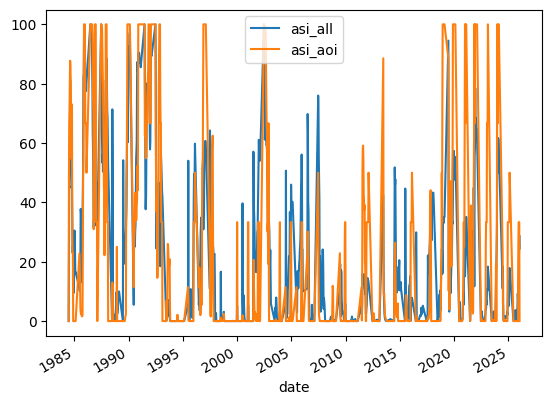

In [111]:
df_asi_dekadal.plot(x="date", y=["asi_all", "asi_aoi"])

In [112]:
df_asi_dekadal["dekad_overall"] = (
    df_asi_dekadal["Month"] - 1
) * 3 + df_asi_dekadal["Dekad"]

In [117]:
df_asi_dekadal.groupby("dekad_overall").size()

dekad_overall
1     42
2     42
3     41
4     41
5     41
18    42
19    42
20    42
21    42
22    42
23    42
24    42
25    42
26    42
27    42
28    42
29    42
30    42
31    42
32    42
33    42
34    42
35    42
36    42
dtype: int64

In [2]:
df_asi_dekadal.pivot(
    columns="Year", index="dekad_overall", values="asi_aoi"
).plot()

NameError: name 'df_asi_dekadal' is not defined

In [118]:
df_asi_dekadal

,Year,Month,Dekad,asi_all,asi_aoi,date,dekad_overall
0,1984,6,3,0.000000,0.000000,1984-06-21,18
1,1984,7,1,25.656376,47.337759,1984-07-01,19
2,1984,7,2,45.492350,66.030645,1984-07-11,20
3,1984,7,3,44.954676,71.653653,1984-07-21,21
4,1984,8,1,65.741821,82.263089,1984-08-01,22
...,...,...,...,...,...,...,...
1000,2025,12,1,9.423357,25.000000,2025-12-01,34
1001,2025,12,2,13.514330,33.333000,2025-12-11,35
1002,2025,12,3,21.572198,33.333000,2025-12-21,36
1003,2026,1,1,28.882262,33.333000,2026-01-01,1


In [119]:
eos_dekad = 9 * 3

In [120]:
eos_dekad

27

In [124]:
df_asi_eos = df_asi_dekadal[df_asi_dekadal["dekad_overall"] == eos_dekad]

<Axes: xlabel='Year'>

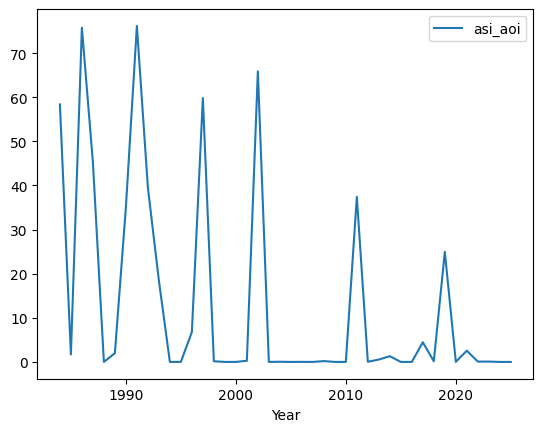

In [125]:
df_asi_eos.plot(x="Year", y="asi_aoi")

In [127]:
df_asi_dekadal

,Year,Month,Dekad,asi_all,asi_aoi,date,dekad_overall
0,1984,6,3,0.000000,0.000000,1984-06-21,18
1,1984,7,1,25.656376,47.337759,1984-07-01,19
2,1984,7,2,45.492350,66.030645,1984-07-11,20
3,1984,7,3,44.954676,71.653653,1984-07-21,21
4,1984,8,1,65.741821,82.263089,1984-08-01,22
...,...,...,...,...,...,...,...
1000,2025,12,1,9.423357,25.000000,2025-12-01,34
1001,2025,12,2,13.514330,33.333000,2025-12-11,35
1002,2025,12,3,21.572198,33.333000,2025-12-21,36
1003,2026,1,1,28.882262,33.333000,2026-01-01,1


In [128]:
blob_name = f"{PROJECT_PREFIX}/processed/asi/mrt_asi_dekadal.parquet"
stratus.upload_parquet_to_blob(df_asi_dekadal, blob_name)